### Proyecto de Análisis de Datos de Supermercado en Python

## Objetivo del proyecto

Analizar datos de una tienda comercial tipo supermercado o retail (similar a Walmart) para identificar:

Productos más vendidos
Categorías con mayores ingresos
Tendencias de ventas
Clientes más frecuentes
Métodos de pago más utilizados
Ciudades con mayor volumen de ventas

##  Herramientas utilizadas
Python
pandas
matplotlib
GitHub

## Descripción del Proyecto

La empresa es una tienda comercial tipo supermercado similar a Walmart, donde se venden productos de diferentes categorías como alimentos, limpieza, electrónica y hogar.

El objetivo es analizar las ventas para identificar patrones de compra, productos más vendidos y comportamiento de clientes.

In [25]:
# IMPORTAR LIBRERIAS

import pandas as pd
import matplotlib.pyplot as plt

In [26]:
# CARGAR MI DATASET

df = pd.read_csv("ecommerce_retail_dataset.csv")

## ANALIZAR EL DATASET

In [27]:
df.head()

,fecha_compra,producto,categoria,cantidad,precio_unitario,cliente,ciudad,metodo_pago,estado_envio,total_venta
0,2024-07-21,Televisión,Electrónica,7,10875.33,Cliente_40,Guadalajara,Transferencia,En camino,76127.31
1,2024-09-12,Detergente,Limpieza,6,120.47,Cliente_2,Guadalajara,PayPal,En camino,722.82
2,2024-03-26,Licuadora,Electrónica,4,1939.77,Cliente_81,Mérida,Tarjeta,En camino,7759.08
3,2024-05-29,Papel Higiénico,Hogar,2,84.66,Cliente_41,Toluca,PayPal,Cancelado,169.32
4,2024-08-22,Televisión,Electrónica,6,12336.18,Cliente_12,Guadalajara,Tarjeta,En camino,74017.08


In [28]:
# instruccion para conocer el tipo de datos, cantidad de datos nulos.
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   fecha_compra     700 non-null    object 
 1   producto         700 non-null    object 
 2   categoria        700 non-null    object 
 3   cantidad         700 non-null    int64  
 4   precio_unitario  700 non-null    float64
 5   cliente          700 non-null    object 
 6   ciudad           700 non-null    object 
 7   metodo_pago      700 non-null    object 
 8   estado_envio     700 non-null    object 
 9   total_venta      700 non-null    float64
dtypes: float64(2), int64(1), object(7)
memory usage: 54.8+ KB


In [29]:
#con esta instruccion conocere la estadistica básica de mi dataset como:
#  promedio, min, max, desviacion estandar, etc  

df.describe()


,cantidad,precio_unitario,total_venta
count,700.000000,700.000000,700.000000
mean,4.045714,1465.342243,5745.585900
std,2.034234,3739.845637,16602.712456
min,1.000000,16.040000,22.250000
25%,2.000000,40.217500,140.422500
50%,4.000000,75.900000,256.880000
75%,6.000000,120.885000,632.700000
max,7.000000,16643.480000,103536.300000


In [30]:
# CONVERTIR TIPO DE DATO DE MI COLUMNA FECHA, YA QUE SE ENCUENTRA COMO OBJECT.
df["fecha_compra"] = pd.to_datetime(df["fecha_compra"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   fecha_compra     700 non-null    datetime64[ns]
 1   producto         700 non-null    object        
 2   categoria        700 non-null    object        
 3   cantidad         700 non-null    int64         
 4   precio_unitario  700 non-null    float64       
 5   cliente          700 non-null    object        
 6   ciudad           700 non-null    object        
 7   metodo_pago      700 non-null    object        
 8   estado_envio     700 non-null    object        
 9   total_venta      700 non-null    float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(6)
memory usage: 54.8+ KB


In [31]:
# REVISAR VALORES NULOS DE MI DATASET

df.isnull().sum()

fecha_compra       0
producto           0
categoria          0
cantidad           0
precio_unitario    0
cliente            0
ciudad             0
metodo_pago        0
estado_envio       0
total_venta        0
dtype: int64

In [32]:
#PARA VISUALIZAR EL TOTAL DE PRODUCTOS CON .nunique()

total_productos = df['producto'].nunique()
productos = df['producto'].unique()

print("Total de productos:")
print(total_productos)
print(productos)

Total de productos:
10
['Televisión' 'Detergente' 'Licuadora' 'Papel Higiénico' 'Cereal' 'Arroz'
 'Refresco' 'Pan' 'Leche' 'Shampoo']


In [33]:
# PARA VISUALIZAR EL TOTAL DE CIUADADES

total_ciudades = df['ciudad'].nunique()
ciudades = df['ciudad'].unique()

print("Total de ciudades:")
print(total_ciudades)
print(ciudades)

Total de ciudades:
7
['Guadalajara' 'Mérida' 'Toluca' 'Querétaro' 'Puebla' 'CDMX' 'Monterrey']


### ANALIZANDO INFORMACION DEL DATASET DE SUPERMERCADO

In [34]:
# VENTAS TOTALES
ventas_totales = df["total_venta"].sum()
print("Ventas_Totales:")
print(ventas_totales)

Ventas_Totales:
4021910.13


In [35]:
# PRODUCTOS MAS VENDIDOS

ventas_productos = df.groupby("producto")["total_venta"].sum().sort_values(ascending=False)
print(ventas_productos)

producto
Televisión         3385954.76
Licuadora           484440.26
Detergente           33645.41
Papel Higiénico      32586.12
Shampoo              21645.28
Cereal               20660.29
Arroz                13531.00
Leche                12358.03
Refresco             11148.28
Pan                   5940.70
Name: total_venta, dtype: float64


In [36]:
# VENTAS POR CATEGORIA

ventas_categoria = df.groupby("categoria")["total_venta"].sum().sort_values(ascending=False)
print(ventas_categoria)

categoria
Electrónica         3870395.02
Alimentos             38959.02
Limpieza              33645.41
Hogar                 32586.12
Cuidado Personal      21645.28
Despensa              13531.00
Bebidas               11148.28
Name: total_venta, dtype: float64


In [37]:
# VENTAS POR CIUDAD

ventas_ciudad = df.groupby("ciudad")["total_venta"].sum().sort_values(ascending=False)
print(ventas_ciudad)

ciudad
Mérida         823352.29
CDMX           662709.56
Toluca         631827.69
Guadalajara    558593.72
Puebla         482732.04
Querétaro      454835.12
Monterrey      407859.71
Name: total_venta, dtype: float64


In [38]:
# VENTAS POR CIUDAD Y PRODUCTO

ventas_ciudad_producto = df.pivot_table(
    values='total_venta',
    index='ciudad',
    columns='producto',
    aggfunc='sum'
)

print(ventas_ciudad_producto)

producto       Arroz   Cereal  Detergente    Leche  Licuadora      Pan  \
ciudad                                                                   
CDMX         1555.56  2851.84     6474.44  2345.72  106342.27   872.22   
Guadalajara  2453.06  2927.31     7060.70  1503.52   27407.65   767.89   
Monterrey    3890.29  3167.46     5388.61  1330.29   57750.09   993.61   
Mérida       1275.00  2034.95     4274.59   463.45   64165.70   596.37   
Puebla       1885.30  4285.45     3088.64  1938.06   83077.44   925.94   
Querétaro    1481.10  1991.50     3376.48  2447.48   61594.50  1075.24   
Toluca        990.69  3401.78     3981.95  2329.51   84102.61   709.43   

producto     Papel Higiénico  Refresco  Shampoo  Televisión  
ciudad                                                       
CDMX                 7178.07   1514.49  1962.98   531611.97  
Guadalajara          3579.57   2036.50  3895.20   506962.32  
Monterrey            6975.37   2533.41  3070.20   322760.38  
Mérida               43

In [39]:
## METODOS DE PAGO MAS USADOS POR LOS CLIENTES

metodos_pago = df['metodo_pago'].value_counts()

print(metodos_pago)

metodo_pago
Transferencia    184
Efectivo         179
PayPal           175
Tarjeta          162
Name: count, dtype: int64


In [40]:
# VENTAS POR CIUDAD Y PRODUCTO

tendencia_ciudad_producto = df.groupby(['fecha_compra', 'ciudad', 'producto'])['total_venta'].sum().reset_index()

print(tendencia_ciudad_producto)

    fecha_compra       ciudad         producto  total_venta
0     2024-01-01  Guadalajara  Papel Higiénico        79.27
1     2024-01-01    Querétaro         Refresco       109.11
2     2024-01-02  Guadalajara            Arroz       146.31
3     2024-01-02    Querétaro            Leche       199.92
4     2024-01-02    Querétaro  Papel Higiénico       204.00
..           ...          ...              ...          ...
682   2024-12-29       Puebla         Refresco       265.26
683   2024-12-29    Querétaro            Leche       226.52
684   2024-12-29       Toluca              Pan        91.53
685   2024-12-30       Mérida       Televisión     81525.99
686   2024-12-30       Toluca            Leche       155.68

[687 rows x 4 columns]


In [41]:
# TENDECIAS DE vENTAS

ventas_fecha = df.groupby('fecha_compra')['total_venta'].sum()

print(ventas_fecha)

fecha_compra
2024-01-01       188.38
2024-01-02       550.23
2024-01-03     23633.32
2024-01-04    104084.02
2024-01-05       162.30
                ...    
2024-12-26       972.73
2024-12-27      1227.00
2024-12-28     43750.94
2024-12-29       812.91
2024-12-30     81681.67
Name: total_venta, Length: 308, dtype: float64


In [42]:
#CREE LA VARIALBLE VENTAS_PRODUCTO

ventas_producto = df.groupby('producto')['total_venta'] \
    .sum() \
    .sort_values(ascending=False)

print(ventas_producto)

producto
Televisión         3385954.76
Licuadora           484440.26
Detergente           33645.41
Papel Higiénico      32586.12
Shampoo              21645.28
Cereal               20660.29
Arroz                13531.00
Leche                12358.03
Refresco             11148.28
Pan                   5940.70
Name: total_venta, dtype: float64


### VISUALIZACIONES

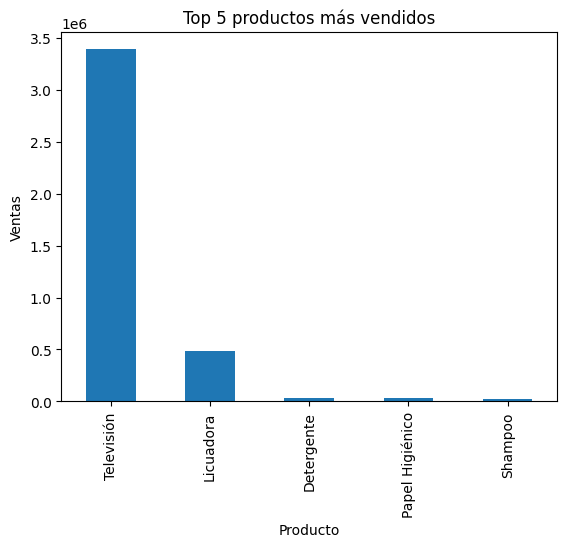

In [43]:
# TOP 5 DE LOS PRODUCTOS MAS VENDIDOS

ventas_producto.head(5).plot(kind='bar')

plt.title('Top 5 productos más vendidos')
plt.xlabel('Producto')
plt.ylabel('Ventas')

plt.show()

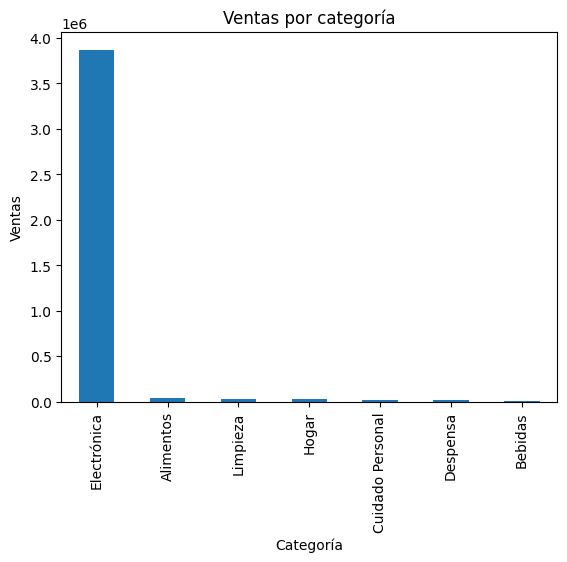

In [44]:
# VENTAS POR CATEGORIA

ventas_categoria.plot(kind='bar')

plt.title('Ventas por categoría')
plt.xlabel('Categoría')
plt.ylabel('Ventas')

plt.show()

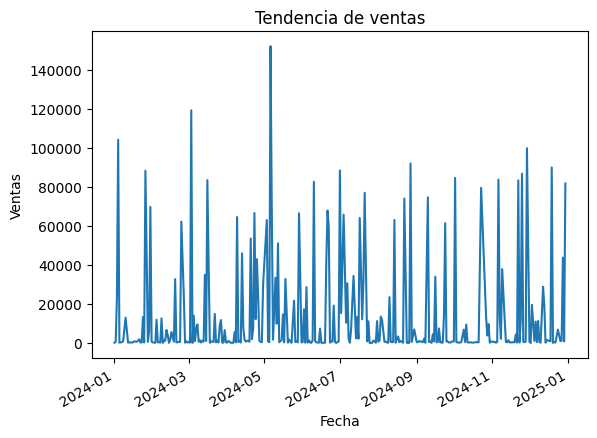

In [45]:
#GRAFICO DE TENDENCIA DE VENTAS

ventas_fecha.plot()

plt.title('Tendencia de ventas')
plt.xlabel('Fecha')
plt.ylabel('Ventas')

plt.show()

In [46]:
#CREAR COLUMNA DE MES

df['mes'] = df['fecha_compra'].dt.month_name()

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   fecha_compra     700 non-null    datetime64[ns]
 1   producto         700 non-null    object        
 2   categoria        700 non-null    object        
 3   cantidad         700 non-null    int64         
 4   precio_unitario  700 non-null    float64       
 5   cliente          700 non-null    object        
 6   ciudad           700 non-null    object        
 7   metodo_pago      700 non-null    object        
 8   estado_envio     700 non-null    object        
 9   total_venta      700 non-null    float64       
 10  mes              700 non-null    object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(7)
memory usage: 60.3+ KB


In [47]:
#VENTA POR MES

ventas_mes = df.groupby('mes')['total_venta'].sum()

print(ventas_mes)

mes
April        374042.60
August       305028.63
December     321370.77
February     168378.01
January      328730.62
July         482579.36
June         332423.01
March        321967.40
May          523912.96
November     442335.97
October      213375.25
September    207765.55
Name: total_venta, dtype: float64


In [48]:
#EXPORTAR LOS RESULTADOS A UN ARCHIVO CSV

ventas_producto.to_csv("ventas_por_producto.csv")